In [ ]:
%load_ext autoreload
%autoreload 2

In [39]:
from torch import nn
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
from model_torch import CNNModel, train_loop, test_loop, train_model, ResNet50Model
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np

### Define Data Augmentation and Data Loader

In [13]:

data_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAutocontrast(0.1),
    v2.ToImage(),                          # 1. Converts PIL Image to a Tensor image
    v2.ToDtype(torch.float32, scale=True), # 2. Converts to Float32 AND sca# les values to [0.0, 1.0]
    # v2.ToTensor(),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Always last
])
generators = torch.Generator().manual_seed(42)

train_dataset = datasets.ImageFolder("data", transform=data_transforms)
train_dataset, val_dataset = random_split(train_dataset, [.8, .2], generator=generators)
val_dataset, test_dataset = random_split(val_dataset, [.5, .5], generator=generators)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)


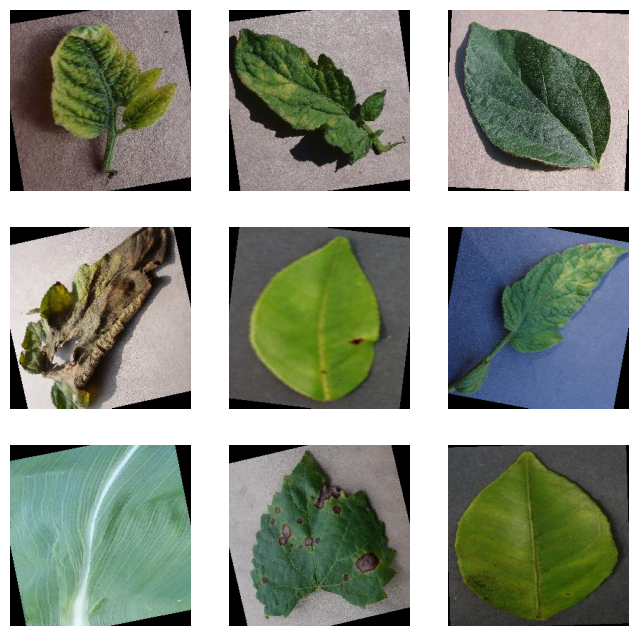

In [25]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    # plt.title(labels_map[label])
    plt.axis("off")
    img_np = img.squeeze().permute(1, 2, 0).detach().cpu().numpy()
    img_np = (img_np * std) + mean
    img_np = np.clip(img_np, 0.0, 1.0)
    plt.imshow(img_np)
plt.show()

In [14]:
num_classes = len(train_dataset.dataset.classes)
print(f"Num Classes {num_classes}")
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
print(device)

Num Classes 39
Using mps device
mps


In [44]:
learning_rate = 1e-3
weight_decay = 1e-4
batch_size = 64
epochs = 3 # use small epochs for transfer learning


# model = CNNModel(num_classes).to(device)
model = ResNet50Model(num_classes).to(device)
optimizer = torch.optim.AdamW([
    {
        "params": model.backbone.layer4.parameters(), # in case of fine tune pretrained weights
        "lr": 1e-4,
    },
    {
        "params": model.classifier.parameters(),
        "lr": 1e-3
    },
], weight_decay=weight_decay)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs, # number of epochs
    eta_min=1e-6
)
 
loss_fn = nn.CrossEntropyLoss()

In [45]:
# for param in model.backbone.layer4.parameters():
#     param.requires_grad = True   

for param in model.parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [ ]:

history = train_model(epochs, model, train_dataloader, val_dataloader, loss_fn, optimizer, scheduler, batch_size, device, num_classes)
print(history)

loss: 0.052667  [   64/44359]


In [46]:
weights_path = "save/resnet_50_cnn_torch.pth"
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
print("Weights successfully loaded into model.")

Weights successfully loaded into model.


In [24]:
weights_path = "save/resnet_50_cnn_torch.pth"
torch.save(model.state_dict(), weights_path)
print(f"Weights successfully saved to {weights_path}")


Weights successfully saved to save/resnet_50_cnn_torch.pth


In [25]:
history

{'train_acc': [0.869451520548254, 0.9501566762100138, 0.9612254559390428],
 'train_loss': [0.5005337017392391, 0.1584213218606085, 0.12099636469293998],
 'val_acc': [0.9477006311992786, 0.9617673579801623, 0.9671776375112714],
 'val_loss': [0.17981409212981148, 0.12418650343329057, 0.10482904323558698],
 'val_precision': 0.9473261833190918,
 'val_recall': 0.9469137787818909,
 'val_f1': 0.9464544653892517}

In [26]:
print("Precision:", history["val_precision"])
print("Recall:", history["val_recall"])
print("F1:", history["val_f1"])

Precision: 0.9473261833190918
Recall: 0.9469137787818909
F1: 0.9464544653892517


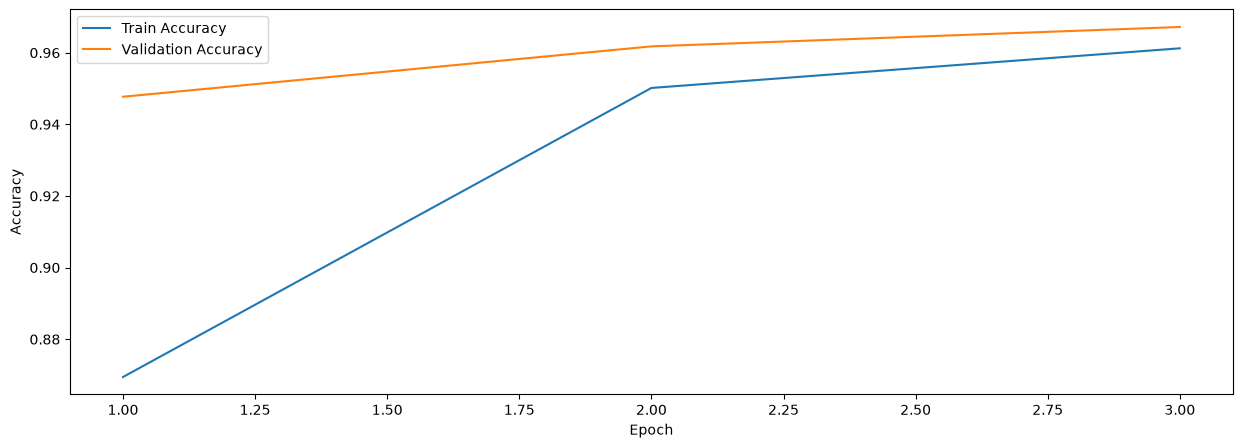

In [27]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(15,5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

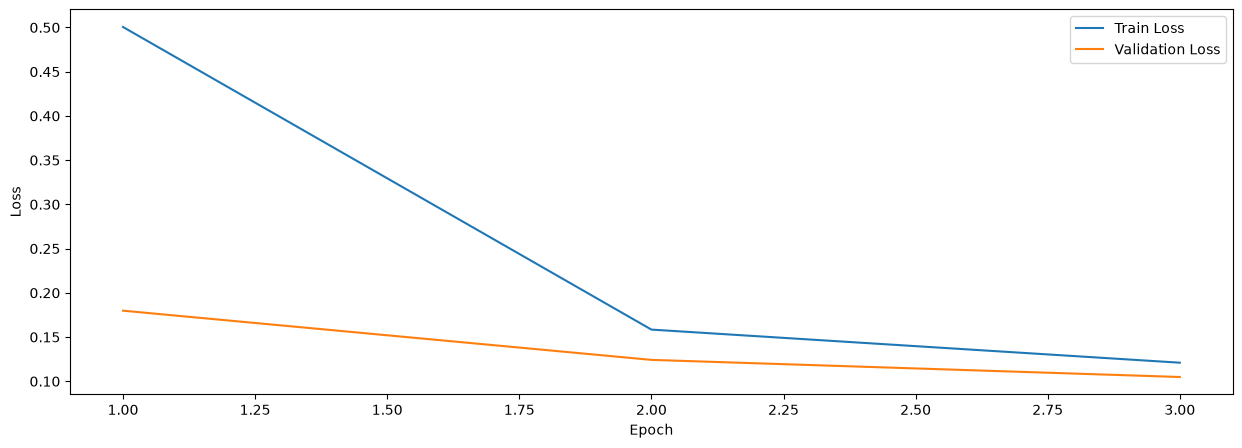

In [28]:
plt.figure(figsize=(15,5))

plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()